### IMPORTING THE LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### DATA MANIPULATION AND CLEANING

Creating DataFrame

In [3]:
df= pd.read_csv('Movie dataset.csv', encoding='latin-1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


DataFrame Information

In [4]:
print("\nDataset Information:\n")
df.info()

print(f"\nDataset Shape: {df.shape}")


Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 2.3 MB

Dataset Shape: (15509, 10)


Column Name

In [5]:
column_name = df.columns.tolist()
print(f'Column Names: {column_name}')

Column Names: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


Colum Datatype

In [6]:
print(f'Data Types of each column:\n')
df.dtypes

Data Types of each column:



Name            str
Year            str
Duration        str
Genre           str
Rating      float64
Votes           str
Director        str
Actor 1         str
Actor 2         str
Actor 3         str
dtype: object

Checking null values

In [7]:
null_counts = df.isnull().sum()
print(f'Null Values in each column:\n')
null_counts

Null Values in each column:



Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

Dropping null values

In [8]:
rows_before = df.shape[0]
df = df.dropna()
rows_after = df.shape[0]

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before cleaning: 15509
Rows after cleaning: 5659
Rows removed: 9850


Datatype conversion

In [9]:
# Remove leading and trailing spaces from string columns
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
# Clean 'Year' column to extract numeric year
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})', expand=False)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
# Clean 'Duration' column to extract numeric duration
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)', expand=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


### EXPLORATORY DATA ANALYSIS

Distribution of movie ratings

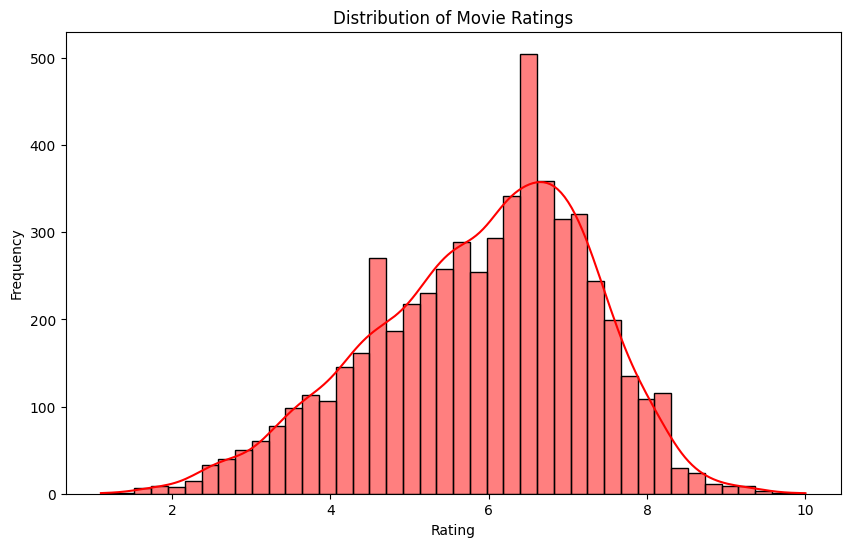

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['Rating'], kde=True, color='red')
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Movie Runtime VS Movie ratings

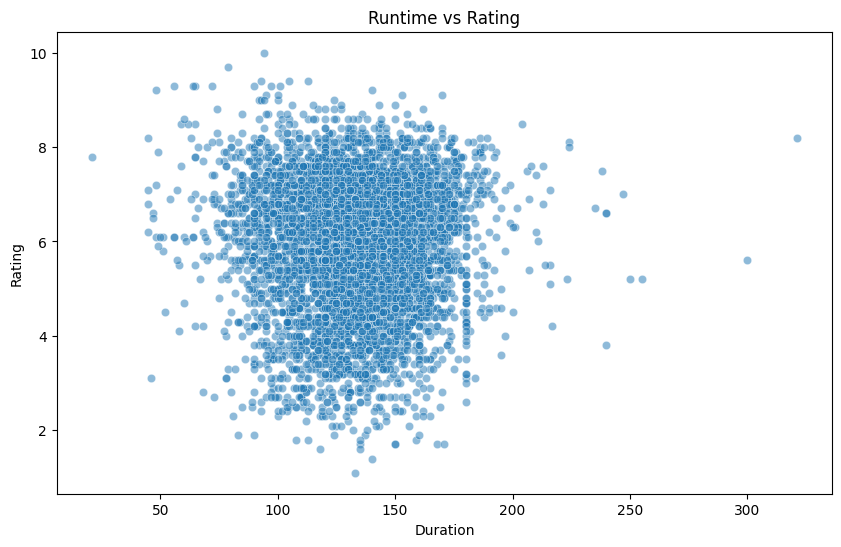

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Duration', y='Rating', data=df, alpha=0.5)
plt.title("Runtime vs Rating")
plt.xlabel("Duration")
plt.ylabel("Rating")
plt.show()

## MOVIE RATING PREDICTION MODEL

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define features and target
features = ["Genre", "Director", "Year", "Duration", "Actor 1", "Actor 2", "Actor 3"]
target = "Rating"

df = df[features + [target]]

#Identify categorical and numerical features
categorical = ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]
numerical = ["Year", "Duration"]

#Train-test split
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Preprocessing + Random Forest model
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", ["Year", "Duration"])
    ]
)

model = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

# Train model
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print("\n--- Random Forest Model Evaluation ---")

model_mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", model_mse)

model_r2 = r2_score(y_test, y_pred)
print("R^2 Score:", model_r2)


--- Random Forest Model Evaluation ---
Mean Squared Error: 1.5168843092854338
R^2 Score: 0.18083460825982156


Predicting movie rating

In [13]:
# Predict example movie
sample = pd.DataFrame({
    "Genre": ["Action"],
    "Director": ["Anurag Kashyap"],
    "Actor 1": ["Actor A"],
    "Actor 2": ["Actor B"],
    "Actor 3": ["Actor C"],
    "Year": [2020],
    "Duration": [150]
})

print("\nPredicted Rating for sample movie:", model.predict(sample)[0])


Predicted Rating for sample movie: 6.605999999999995
